# 03 — Model Evaluation

Train/test evaluation for a single play-type classifier. **Generalized**: set
`MODEL_KEY` in the config cell below to any model in the registry
(`baseline`, `logistic_regression`, `random_forest`, `xgboost`) and re-run — the
rest of the notebook is identical. The model + hyperparameters come from
`configs/models/<MODEL_KEY>.yaml` (same source the CLI pipeline uses).

Contents: metrics table (accuracy / precision / recall / F1 / support) → confusion
matrix → ROC curve → precision-recall curve, each shown for **train and test**.

## 0. Config — pick the model here

In [1]:
# ── The only knob: which model to evaluate ──────────────────────────────────
MODEL_KEY = "xgboost"   # baseline | logistic_regression | random_forest | xgboost

TEST_SIZE = 0.2
SEED = 42                # matches the pipeline's StratifiedKFold seed
THRESHOLD = 0.5          # probability cutoff for class predictions

## 1. Setup

In [2]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Run everything from the repo root so repo-relative paths (parquet, configs)
# resolve exactly as they do for the CLI.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

from src.data.loaders import load_play_type_dataset
from src.data.schema import MODEL_REGISTRY_KEYS, TARGET_CLF
from src.models import CLASSIFIER_BUILDERS
from src.utils.experiment_profile import load_experiment_profile, use_experiment_profile

assert MODEL_KEY in MODEL_REGISTRY_KEYS, f"{MODEL_KEY!r} not in {MODEL_REGISTRY_KEYS}"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CLASS_NAMES = ["run", "pass"]   # target encoded pass=1 / run=0
print(f"Evaluating: {MODEL_KEY}")

Evaluating: xgboost


## 2. Load data, split, impute

Stratified train/test split on the modeling parquet (the current feature-selected
dataset). Median imputation is fit on **train only** and applied to both splits —
the same leakage-safe rule the CV pipeline uses.

In [3]:
X, y = load_play_type_dataset()
print(f"Dataset: {X.shape[0]:,} rows × {X.shape[1]} features | target '{TARGET_CLF}'")
print(f"Class balance: {dict(y.value_counts().rename({1: 'pass', 0: 'run'}))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Fit imputer on train, transform both (one-hot cols have no NaN; harmless).
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X.columns, index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test), columns=X.columns, index=X_test.index
)
print(f"Train: {len(X_train_imp):,}  |  Test: {len(X_test_imp):,}")

Dataset: 276,286 rows × 65 features | target 'play_type'


Class balance: {'pass': 160936, 'run': 115350}


Train: 221,028  |  Test: 55,258


## 3. Build and fit the model

The estimator and its hyperparameters are resolved from
`configs/models/<MODEL_KEY>.yaml` via the same profile mechanism the CLI uses.

In [4]:
config_path = Path("configs/models") / f"{MODEL_KEY}.yaml"
profile = load_experiment_profile(config_path)

with use_experiment_profile(profile):
    model = CLASSIFIER_BUILDERS[MODEL_KEY]()
    model.fit(X_train_imp, y_train)

print(f"Fitted {MODEL_KEY} from {config_path}")
print("Hyperparameters:", profile.model_hyperparameters(MODEL_KEY))

# Predicted P(pass) and hard labels for both splits.
proba_train = model.predict_proba(X_train_imp)[:, 1]
proba_test = model.predict_proba(X_test_imp)[:, 1]
pred_train = (proba_train >= THRESHOLD).astype(int)
pred_test = (proba_test >= THRESHOLD).astype(int)

Fitted xgboost from configs/models/xgboost.yaml
Hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'reg_lambda': 1.0, 'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0}


## 4. Metrics table

Accuracy, precision, recall, F1-score, and support — per class plus macro/weighted
averages, for train and test side by side.

In [5]:
def metrics_frame(y_true, y_pred, split_label):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    df = pd.DataFrame(report).T
    df["support"] = df["support"].astype(int)
    # Flatten the scalar accuracy row into the same columns.
    acc = accuracy_score(y_true, y_pred)
    df.loc["accuracy", ["precision", "recall", "f1-score"]] = [np.nan, np.nan, acc]
    df.loc["accuracy", "support"] = len(y_true)
    df.columns = pd.MultiIndex.from_product([[split_label], df.columns])
    return df

train_metrics = metrics_frame(y_train, pred_train, "train")
test_metrics = metrics_frame(y_test, pred_test, "test")
metrics_table = pd.concat([train_metrics, test_metrics], axis=1)

print(f"{MODEL_KEY} — classification metrics (threshold={THRESHOLD})")
print(f"ROC-AUC  train={roc_auc_score(y_train, proba_train):.4f}  "
      f"test={roc_auc_score(y_test, proba_test):.4f}")
metrics_table.round(4)

xgboost — classification metrics (threshold=0.5)
ROC-AUC  train=0.8318  test=0.8151


train                               test                   \
             precision  recall f1-score support precision  recall f1-score   
run             0.7128  0.6898   0.7011   92280    0.7025  0.6788   0.6905   
pass            0.7827  0.8008   0.7916  128748    0.7753  0.7940   0.7845   
accuracy           NaN     NaN   0.7545  221028       NaN     NaN   0.7459   
macro avg       0.7478  0.7453   0.7464  221028    0.7389  0.7364   0.7375   
weighted avg    0.7535  0.7545   0.7539  221028    0.7449  0.7459   0.7453   

                      
             support  
run            23070  
pass           32188  
accuracy       55258  
macro avg      55258  
weighted avg   55258

## 5. Confusion matrix — train and test

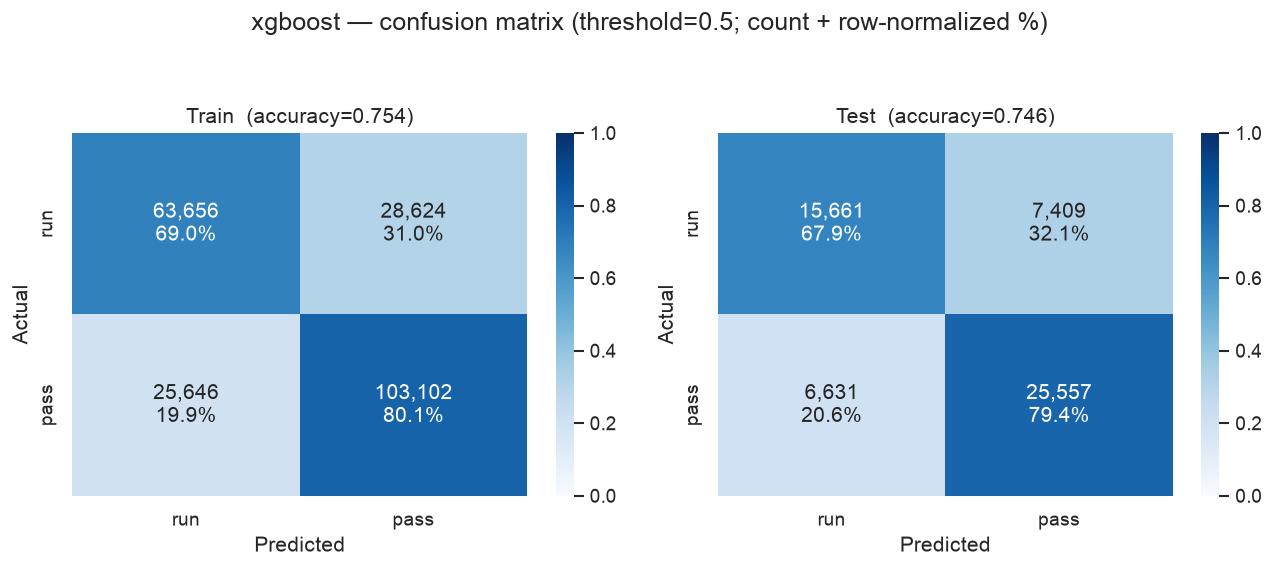

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (yt, yp, label) in zip(
    axes,
    [(y_train, pred_train, "Train"), (y_test, pred_test, "Test")],
):
    cm = confusion_matrix(yt, yp)
    acc = accuracy_score(yt, yp)
    # Row-normalized proportions (share of each actual class).
    cm_prop = cm / cm.sum(axis=1, keepdims=True)
    annot = np.array([
        [f"{cm[i, j]:,}\n{cm_prop[i, j]:.1%}" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])
    sns.heatmap(
        cm_prop, annot=annot, fmt="", cmap="Blues", cbar=True,
        vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    )
    ax.set_title(f"{label}  (accuracy={acc:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle(
    f"{MODEL_KEY} — confusion matrix (threshold={THRESHOLD}; "
    "count + row-normalized %)", y=1.05,
)
plt.tight_layout()
plt.show()

## 6. ROC curve — train and test

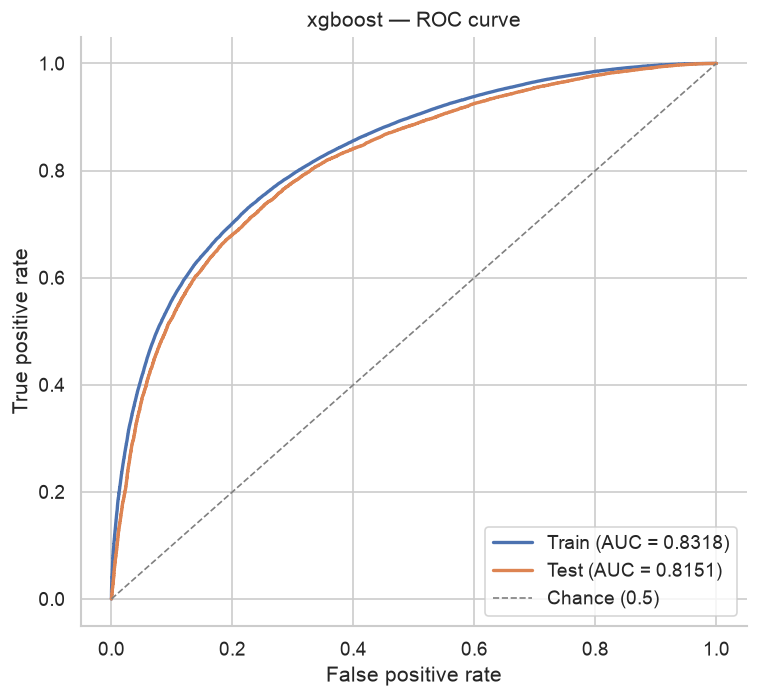

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for proba, yt, label in [
    (proba_train, y_train, "Train"),
    (proba_test, y_test, "Test"),
]:
    fpr, tpr, _ = roc_curve(yt, proba)
    auc = roc_auc_score(yt, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], ls="--", c="gray", lw=1, label="Chance (0.5)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"{MODEL_KEY} — ROC curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Precision-recall curve — train and test

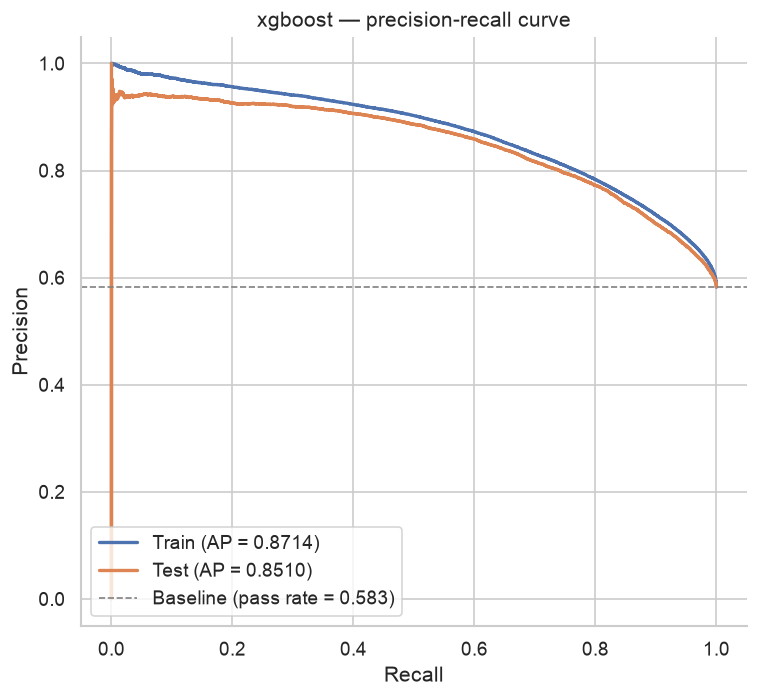

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for proba, yt, label in [
    (proba_train, y_train, "Train"),
    (proba_test, y_test, "Test"),
]:
    precision, recall, _ = precision_recall_curve(yt, proba)
    ap = average_precision_score(yt, proba)
    ax.plot(recall, precision, lw=2, label=f"{label} (AP = {ap:.4f})")

baseline_rate = y_test.mean()
ax.axhline(baseline_rate, ls="--", c="gray", lw=1,
           label=f"Baseline (pass rate = {baseline_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"{MODEL_KEY} — precision-recall curve")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()